# Métodos de passo único para approximas as soluções de Equações DIferenciais Ordinarias

Este notebook abrange a implementação de métodos de passo único para diferentes problemas de ODEs.

## 1. Importando as librarias de Python necessárias

Usaremos Numpy pra cálculos numéricos, Sympy para tratamento simbólico e Matplotlib para visualização.

In [ ]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig_size = (12, 5)

## 2. Define Test ODEs with Analytical Solutions

We'll work with three test problems with known analytical solutions:
1. $y' = -2y$, $y(0) = 1$ → Analytical: $y(t) = e^{-2t}$
2. $y' = y(1-y)$ (Logistic), $y(0) = 0.1$ → Analytical: $y(t) = \frac{1}{1 + 9e^{-t}}$
3. $y' = t + y$, $y(0) = 0$ → Analytical: $y(t) = e^t - t - 1$

In [ ]:
# Define test ODEs and their analytical solutions

# Problem 1: Exponential decay
def ode1(y, t):
    return -2 * y

def analytical1(t):
    return np.exp(-2 * t)

# Problem 2: Logistic equation
def ode2(y, t):
    return y * (1 - y)

def analytical2(t):
    return 1 / (1 + 9 * np.exp(-t))

# Problem 3: Linear non-homogeneous ODE
def ode3(y, t):
    return t + y

def analytical3(t):
    return np.exp(t) - t - 1

# Store problems in a dictionary for easy access
problems = {
    'exp_decay': {'ode': ode1, 'analytical': analytical1, 'y0': 1.0, 
                  'name': "y' = -2y", 'latex': r"$y' = -2y$"},
    'logistic': {'ode': ode2, 'analytical': analytical2, 'y0': 0.1, 
                 'name': "y' = y(1-y)", 'latex': r"$y' = y(1-y)$"},
    'linear': {'ode': ode3, 'analytical': analytical3, 'y0': 0.0, 
               'name': "y' = t + y", 'latex': r"$y' = t + y$"}
}

## 3. Euler's Method

The simplest one-step method is Euler's method:
$$y_{n+1} = y_n + h \cdot f(t_n, y_n)$$

where $h$ is the step size, $t_n = t_0 + nh$, and $f(t, y) = \frac{dy}{dt}$.

**Characteristics:**
- Order of accuracy: $O(h)$ (first-order)
- Local truncation error: $O(h^2)$
- Global error: $O(h)$

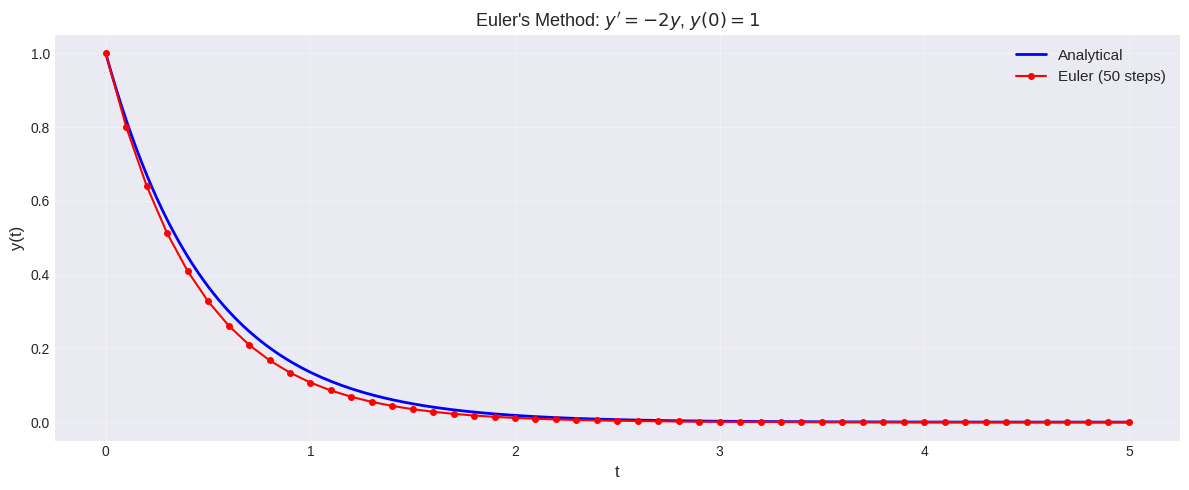

In [5]:
def euler_method(f, t_span, y0, num_steps):
    """
    Euler's method for solving ODE
    
    Parameters:
    f: function, ODE function dy/dt = f(y, t)
    t_span: tuple, (t_start, t_end)
    y0: float, initial condition
    num_steps: int, number of steps
    
    Returns:
    t: numpy array of time points
    y: numpy array of solution values
    """
    t_start, t_end = t_span
    h = (t_end - t_start) / num_steps
    t = np.linspace(t_start, t_end, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = y0
    
    for i in range(num_steps):
        y[i + 1] = y[i] + h * f(y[i], t[i])
    
    return t, y

# Test Euler's method on the exponential decay problem
t_euler, y_euler = euler_method(ode1, (0, 5), 1.0, 50)
t_analytical = np.linspace(0, 5, 200)
y_analytical = analytical1(t_analytical)

plt.figure(figsize=fig_size)
plt.plot(t_analytical, y_analytical, 'b-', linewidth=2, label='Analytical')
plt.plot(t_euler, y_euler, 'ro-', markersize=4, label='Euler (50 steps)')
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.title("Euler's Method: $y' = -2y$, $y(0) = 1$", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Heun's Method (RK2)

Heun's method is a second-order Runge-Kutta method that improves upon Euler by using a predictor-corrector approach:

$$y_{n+1} = y_n + \frac{h}{2}(f(t_n, y_n) + f(t_{n+1}, y_n + h \cdot f(t_n, y_n)))$$

**Characteristics:**
- Order of accuracy: $O(h^2)$ (second-order)
- Local truncation error: $O(h^3)$
- Global error: $O(h^2)$
- More accurate than Euler but with similar computational cost

In [ ]:
def heun_method(f, t_span, y0, num_steps):
    """
    Heun's method (RK2) for solving ODE
    
    Parameters:
    f: function, ODE function dy/dt = f(y, t)
    t_span: tuple, (t_start, t_end)
    y0: float, initial condition
    num_steps: int, number of steps
    
    Returns:
    t: numpy array of time points
    y: numpy array of solution values
    """
    t_start, t_end = t_span
    h = (t_end - t_start) / num_steps
    t = np.linspace(t_start, t_end, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = y0
    
    for i in range(num_steps):
        k1 = f(y[i], t[i])
        k2 = f(y[i] + h * k1, t[i] + h)
        y[i + 1] = y[i] + (h / 2) * (k1 + k2)
    
    return t, y

# Test Heun's method on the exponential decay problem
t_heun, y_heun = heun_method(ode1, (0, 5), 1.0, 50)

plt.figure(figsize=fig_size)
plt.plot(t_analytical, y_analytical, 'b-', linewidth=2, label='Analytical')
plt.plot(t_euler, y_euler, 'ro-', markersize=4, alpha=0.6, label='Euler (50 steps)')
plt.plot(t_heun, y_heun, 'g^-', markersize=4, alpha=0.6, label='Heun/RK2 (50 steps)')
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.title("Comparison: Euler vs Heun's Method for $y' = -2y$", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Runge-Kutta 4th Order Method (RK4)

The classical RK4 method uses four stages per step for high accuracy:

$$k_1 = f(t_n, y_n)$$
$$k_2 = f(t_n + \frac{h}{2}, y_n + \frac{h}{2}k_1)$$
$$k_3 = f(t_n + \frac{h}{2}, y_n + \frac{h}{2}k_2)$$
$$k_4 = f(t_n + h, y_n + hk_3)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

**Characteristics:**
- Order of accuracy: $O(h^4)$ (fourth-order)
- Local truncation error: $O(h^5)$
- Global error: $O(h^4)$
- Excellent accuracy for smooth problems

In [ ]:
def rk4_method(f, t_span, y0, num_steps):
    """
    Runge-Kutta 4th order method for solving ODE
    
    Parameters:
    f: function, ODE function dy/dt = f(y, t)
    t_span: tuple, (t_start, t_end)
    y0: float, initial condition
    num_steps: int, number of steps
    
    Returns:
    t: numpy array of time points
    y: numpy array of solution values
    """
    t_start, t_end = t_span
    h = (t_end - t_start) / num_steps
    t = np.linspace(t_start, t_end, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = y0
    
    for i in range(num_steps):
        k1 = f(y[i], t[i])
        k2 = f(y[i] + 0.5 * h * k1, t[i] + 0.5 * h)
        k3 = f(y[i] + 0.5 * h * k2, t[i] + 0.5 * h)
        k4 = f(y[i] + h * k3, t[i] + h)
        y[i + 1] = y[i] + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
    
    return t, y

# Test RK4 method on the exponential decay problem
t_rk4, y_rk4 = rk4_method(ode1, (0, 5), 1.0, 50)

plt.figure(figsize=fig_size)
plt.plot(t_analytical, y_analytical, 'b-', linewidth=2.5, label='Analytical')
plt.plot(t_euler, y_euler, 'ro-', markersize=3, alpha=0.5, label='Euler')
plt.plot(t_heun, y_heun, 'g^-', markersize=3, alpha=0.5, label='Heun/RK2')
plt.plot(t_rk4, y_rk4, 'ms-', markersize=3, alpha=0.7, label='RK4')
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.title("All Methods: $y' = -2y$ with 50 steps", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparing Methods on Different ODEs

Let's apply all three methods to each of our test problems and visualize the results side-by-side.

In [ ]:
def compare_methods(problem_key, t_end=None, num_steps=50):
    """Compare all three methods on a given problem"""
    problem = problems[problem_key]
    f = problem['ode']
    analytical = problem['analytical']
    y0 = problem['y0']
    
    if t_end is None:
        t_end = 5 if problem_key != 'logistic' else 10
    
    t_span = (0, t_end)
    
    # Solve with all methods
    t_euler, y_euler = euler_method(f, t_span, y0, num_steps)
    t_heun, y_heun = heun_method(f, t_span, y0, num_steps)
    t_rk4, y_rk4 = rk4_method(f, t_span, y0, num_steps)
    
    # Analytical solution with fine mesh
    t_analytical = np.linspace(0, t_end, 300)
    y_analytical = analytical(t_analytical)
    
    return (t_euler, y_euler, t_heun, y_heun, t_rk4, y_rk4, 
            t_analytical, y_analytical)

# Compare all three problems
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (problem_key, ax) in enumerate(zip(['exp_decay', 'logistic', 'linear'], axes)):
    problem = problems[problem_key]
    t_end = 10 if problem_key == 'logistic' else 5
    
    results = compare_methods(problem_key, t_end=t_end, num_steps=40)
    t_euler, y_euler, t_heun, y_heun, t_rk4, y_rk4, t_anal, y_anal = results
    
    ax.plot(t_anal, y_anal, 'b-', linewidth=2.5, label='Analytical', zorder=5)
    ax.plot(t_euler, y_euler, 'ro', markersize=3, alpha=0.6, label='Euler')
    ax.plot(t_heun, y_heun, 'g^', markersize=3, alpha=0.6, label='Heun/RK2')
    ax.plot(t_rk4, y_rk4, 'ms', markersize=3, alpha=0.6, label='RK4')
    
    ax.set_xlabel('t', fontsize=11)
    ax.set_ylabel('y(t)', fontsize=11)
    ax.set_title(f"{problem['latex']}", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Accuracy and Convergence Analysis

Now let's analyze how the error decreases as we refine the step size. This is crucial for understanding the convergence properties of each method.

In [ ]:
def compute_max_error(method, f, t_span, y0, analytical, num_steps):
    """Compute maximum absolute error for a given method"""
    t, y = method(f, t_span, y0, num_steps)
    y_exact = analytical(t)
    error = np.abs(y - y_exact)
    return np.max(error)

def convergence_analysis(problem_key, t_end=None, max_steps=500):
    """Analyze convergence for all three methods"""
    problem = problems[problem_key]
    f = problem['ode']
    analytical = problem['analytical']
    y0 = problem['y0']
    
    if t_end is None:
        t_end = 5 if problem_key != 'logistic' else 10
    
    t_span = (0, t_end)
    
    # Array of step numbers to test
    step_counts = np.array([10, 20, 40, 80, 160, 320, max_steps])
    
    # Store errors for each method
    errors_euler = np.zeros(len(step_counts))
    errors_heun = np.zeros(len(step_counts))
    errors_rk4 = np.zeros(len(step_counts))
    
    for i, n_steps in enumerate(step_counts):
        errors_euler[i] = compute_max_error(euler_method, f, t_span, y0, analytical, n_steps)
        errors_heun[i] = compute_max_error(heun_method, f, t_span, y0, analytical, n_steps)
        errors_rk4[i] = compute_max_error(rk4_method, f, t_span, y0, analytical, n_steps)
    
    h = (t_end - 0) / step_counts  # Step size
    
    return h, errors_euler, errors_heun, errors_rk4

# Analyze all three problems
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (problem_key, ax) in enumerate(zip(['exp_decay', 'logistic', 'linear'], axes)):
    problem = problems[problem_key]
    h, err_euler, err_heun, err_rk4 = convergence_analysis(problem_key, max_steps=500)
    
    # Log-log plot
    ax.loglog(h, err_euler, 'ro-', linewidth=2, markersize=6, label='Euler (O(h))')
    ax.loglog(h, err_heun, 'g^-', linewidth=2, markersize=6, label='Heun (O($h^2$))')
    ax.loglog(h, err_rk4, 'ms-', linewidth=2, markersize=6, label='RK4 (O($h^4$))')
    
    # Reference lines showing theoretical slopes
    h_min, h_max = h.min(), h.max()
    ax.loglog([h_min, h_max], 100*np.array([h_min, h_max]), 'r--', alpha=0.3, linewidth=1)
    ax.loglog([h_min, h_max], 10*np.array([h_min**2, h_max**2]), 'g--', alpha=0.3, linewidth=1)
    ax.loglog([h_min, h_max], np.array([h_min**4, h_max**4]), 'm--', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('Step size h', fontsize=11)
    ax.set_ylabel('Max Error', fontsize=11)
    ax.set_title(f"{problem['latex']}", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 8. Exercises with Solutions

Now it's your turn! Complete the following exercises to consolidate your understanding of one-step methods.

### Exercise 1: Implement Midpoint Method (RK2 variant)

The midpoint method is another second-order method:
$$y_{n+1} = y_n + h \cdot f(t_n + \frac{h}{2}, y_n + \frac{h}{2}f(t_n, y_n))$$

**Your task:** Implement the midpoint method and compare it with Heun's method on the linear ODE problem.

In [ ]:
# Exercise 1 Solution
def midpoint_method(f, t_span, y0, num_steps):
    """
    Midpoint method (RK2 variant) for solving ODE
    
    Parameters:
    f: function, ODE function dy/dt = f(y, t)
    t_span: tuple, (t_start, t_end)
    y0: float, initial condition
    num_steps: int, number of steps
    
    Returns:
    t: numpy array of time points
    y: numpy array of solution values
    """
    t_start, t_end = t_span
    h = (t_end - t_start) / num_steps
    t = np.linspace(t_start, t_end, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = y0
    
    for i in range(num_steps):
        k_half = f(y[i] + 0.5 * h * f(y[i], t[i]), t[i] + 0.5 * h)
        y[i + 1] = y[i] + h * k_half
    
    return t, y

# Compare midpoint with Heun
t_span = (0, 5)
t_mid, y_mid = midpoint_method(ode3, t_span, 0.0, 40)
t_heun, y_heun = heun_method(ode3, t_span, 0.0, 40)
t_anal = np.linspace(0, 5, 300)
y_anal = analytical3(t_anal)

plt.figure(figsize=fig_size)
plt.plot(t_anal, y_anal, 'b-', linewidth=2.5, label='Analytical')
plt.plot(t_heun, y_heun, 'g^-', markersize=4, alpha=0.6, label='Heun/RK2')
plt.plot(t_mid, y_mid, 'cs-', markersize=4, alpha=0.6, label='Midpoint')
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.title("Exercise 1: Heun vs Midpoint Method for $y' = t + y$", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare errors
h, err_heun, err_mid, _ = convergence_analysis('linear', t_end=5, max_steps=500)
err_mid_vals = np.array([compute_max_error(midpoint_method, ode3, (0, 5), 0.0, analytical3, n) 
                          for n in np.array([10, 20, 40, 80, 160, 320, 500])])

plt.figure(figsize=(8, 5))
plt.loglog(h, err_heun, 'g^-', linewidth=2, markersize=7, label='Heun/RK2')
plt.loglog(h, err_mid_vals, 'cs-', linewidth=2, markersize=7, label='Midpoint')
plt.xlabel('Step size h', fontsize=12)
plt.ylabel('Max Error', fontsize=12)
plt.title('Exercise 1: Convergence Comparison', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Exercise 2: Solve a Predator-Prey System

The Lotka-Volterra predator-prey model is a system of two first-order ODEs:
$$\frac{dx}{dt} = ax - bxy$$
$$\frac{dy}{dt} = -cy + dxy$$

where $x$ is the prey population, $y$ is the predator population.

With parameters: $a=1.0$, $b=0.1$, $c=1.5$, $d=0.075$, and initial conditions $x_0=10$, $y_0=5$.

**Your task:** Extend one-step methods to handle systems of ODEs and solve the Lotka-Volterra model.

In [ ]:
# Exercise 2 Solution: Systems of ODEs

def rk4_system(f, t_span, y0, num_steps):
    """
    RK4 method for systems of ODEs
    
    Parameters:
    f: function, system dy/dt = f(y, t), where y is an array
    t_span: tuple, (t_start, t_end)
    y0: array, initial conditions for all ODEs
    num_steps: int, number of steps
    
    Returns:
    t: numpy array of time points
    y: numpy array of solution values (num_steps+1 x len(y0))
    """
    t_start, t_end = t_span
    h = (t_end - t_start) / num_steps
    t = np.linspace(t_start, t_end, num_steps + 1)
    y = np.zeros((num_steps + 1, len(y0)))
    y[0] = y0
    
    for i in range(num_steps):
        k1 = f(y[i], t[i])
        k2 = f(y[i] + 0.5 * h * k1, t[i] + 0.5 * h)
        k3 = f(y[i] + 0.5 * h * k2, t[i] + 0.5 * h)
        k4 = f(y[i] + h * k3, t[i] + h)
        y[i + 1] = y[i] + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
    
    return t, y

# Lotka-Volterra predator-prey model
def lotka_volterra(y, t, a=1.0, b=0.1, c=1.5, d=0.075):
    """
    y[0] = x (prey), y[1] = y (predator)
    """
    x, y_pred = y
    dx_dt = a*x - b*x*y_pred
    dy_dt = -c*y_pred + d*x*y_pred
    return np.array([dx_dt, dy_dt])

# Solve Lotka-Volterra system
y0 = np.array([10.0, 5.0])
t_span = (0, 50)
t_lv, y_lv = rk4_system(lambda y, t: lotka_volterra(y, t), t_span, y0, 1000)

# Phase plane plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Time series
axes[0].plot(t_lv, y_lv[:, 0], 'b-', linewidth=2, label='Prey (x)')
axes[0].plot(t_lv, y_lv[:, 1], 'r-', linewidth=2, label='Predator (y)')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Population', fontsize=12)
axes[0].set_title('Lotka-Volterra: Time Series', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Phase plane (x vs y)
axes[1].plot(y_lv[:, 0], y_lv[:, 1], 'g-', linewidth=2)
axes[1].plot(y_lv[0, 0], y_lv[0, 1], 'go', markersize=10, label='Start')
axes[1].set_xlabel('Prey (x)', fontsize=12)
axes[1].set_ylabel('Predator (y)', fontsize=12)
axes[1].set_title('Phase Plane', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 3: Stiff ODE Problem

Stiff ODEs are challenging for explicit methods. Consider:
$$y' = -1000(y - \cos(t)) - \sin(t)$$
$$y(0) = 1$$

This ODE has a rapidly decaying component (time scale $\approx 0.001$) and a slowly varying component (time scale $\approx 1$).

**Your task:** 
1. Try solving with Euler and RK4 methods using a uniform step size
2. Explain why explicit methods struggle with stiff problems
3. Compare the computational cost and accuracy

In [ ]:
# Exercise 3 Solution: Stiff ODE

def stiff_ode(y, t, lambda_param=1000):
    """Stiff ODE: y' = -lambda*(y - cos(t)) - sin(t)"""
    return -lambda_param * (y - np.cos(t)) - np.sin(t)

def stiff_analytical(t, lambda_param=1000):
    """Analytical solution"""
    return (1 + lambda_param/(1 + lambda_param**2)) * np.exp(-lambda_param*t) + \
           np.cos(t)/(1 + lambda_param**2) + lambda_param * np.sin(t)/(1 + lambda_param**2)

# The issue with stiff problems
print("Stiff ODE Analysis:")
print("=" * 50)
print("ODE: y' = -1000(y - cos(t)) - sin(t)")
print("Stiffness ratio: 1000:1")
print("\nFor explicit methods, stability requires:")
print("h < 2/1000 ≈ 0.002")
print("To reach t=10, we need > 5000 steps!")
print("\n" + "=" * 50)

# Attempt with Euler and RK4 (may show instability with large h)
h_test = 0.01
num_steps_test = int(10 / h_test)
print(f"\nUsing h = {h_test} ({num_steps_test} steps):")

t_euler, y_euler = euler_method(lambda y, t: stiff_ode(y, t), (0, 10), 1.0, num_steps_test)
t_rk4, y_rk4 = rk4_method(lambda y, t: stiff_ode(y, t), (0, 10), 1.0, num_steps_test)

# Analytical solution with fine mesh
t_anal = np.linspace(0, 10, 500)
y_anal = stiff_analytical(t_anal)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full solution
axes[0].plot(t_anal, y_anal, 'b-', linewidth=2.5, label='Analytical (reference)')
axes[0].plot(t_rk4, y_rk4, 'ms-', markersize=3, alpha=0.6, label=f'RK4 (h={h_test})')
axes[0].set_xlabel('t', fontsize=12)
axes[0].set_ylabel('y(t)', fontsize=12)
axes[0].set_title('Stiff ODE: Full Solution', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Early time behavior
axes[1].plot(t_anal[t_anal <= 0.1], y_anal[t_anal <= 0.1], 'b-', linewidth=2.5, label='Analytical')
axes[1].plot(t_rk4[t_rk4 <= 0.1], y_rk4[t_rk4 <= 0.1], 'ms-', markersize=4, alpha=0.7, label='RK4')
axes[1].set_xlabel('t', fontsize=12)
axes[1].set_ylabel('y(t)', fontsize=12)
axes[1].set_title('Early Time Behavior (Rapid Decay)', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Stiff problems require implicit methods or adaptive step size control")
print("for efficient and stable solutions.")


## Summary and Key Takeaways

### One-Step Methods Comparison

| Method | Order | Stages | Accuracy | Cost |
|--------|-------|--------|----------|------|
| **Euler** | $O(h)$ | 1 | Low | Low |
| **Heun/RK2** | $O(h^2)$ | 2 | Medium | Low-Med |
| **Midpoint** | $O(h^2)$ | 2 | Medium | Low-Med |
| **RK4** | $O(h^4)$ | 4 | High | Medium |

### When to Use Each Method:
- **Euler's method**: Teaching tool, very simple problems, rough estimates
- **Heun/RK2/Midpoint**: Balance of accuracy and simplicity
- **RK4**: Most versatile for smooth problems, good accuracy/cost ratio
- **Implicit methods** (not covered): Necessary for stiff problems

### Important Concepts:
1. **Convergence**: Error decreases as $O(h^p)$ where $p$ is the order
2. **Stability**: Methods have stability regions; Euler is more restrictive than RK4
3. **Local vs Global Error**: Global error is typically one order worse than local error
4. **Stiffness**: Some problems require special treatment (adaptive methods, implicit schemes)

### Further Exploration:
- Implement adaptive step size control
- Study stability regions for different methods
- Explore implicit methods (Backward Euler, Trapezoidal rule)
- Apply to real-world problems in physics, chemistry, biology